# Thông tin tổng quan của dataset

In [1]:
import pandas as pd

# Đọc file CSV vào DataFrame
file_path = r'D:\UNI DOCS\OLAP\raw-data\cutoff-scores.csv'
df = pd.read_csv(file_path, encoding='utf-8')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 147671 entries, 0 to 147670
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   school_id                 147671 non-null  str    
 1   school_name               147671 non-null  str    
 2   school_type               147671 non-null  str    
 3   school_short_name         138565 non-null  str    
 4   province_id               147671 non-null  int64  
 5   province_name             147671 non-null  str    
 6   score_code                145478 non-null  str    
 7   score_name                147088 non-null  str    
 8   score_blocks              118135 non-null  str    
 9   score_mark                145686 non-null  float64
 10  score_year                143459 non-null  float64
 11  score_introtext           33581 non-null   str    
 12  score_formula             32022 non-null   str    
 13  score_is_converted_score  147513 non-null  float64
 14 

,school_id,school_name,school_type,school_short_name,province_id,province_name,score_code,score_name,score_blocks,score_mark,score_year,score_introtext,score_formula,score_is_converted_score,score_admission_name
0,CDD0209,Trường Cao Đẳng Sài Gòn,Cao đẳng,NaN,23,TP Hồ Chí Minh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CDT026,Trường Cao đẳng Giao thông vận tải trung ương VI,Cao đẳng,NaN,23,TP Hồ Chí Minh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CDD0229,Trường Cao đẳng Bách khoa Nam Sài Gòn,Cao đẳng,NaN,23,TP Hồ Chí Minh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CDD0410,Trường Cao Đẳng Công Nghệ Ngoại Thương,Cao đẳng,NaN,23,TP Hồ Chí Minh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CDT0218,Trường Cao đẳng Thủ Thiêm – TP. Hồ Chí Minh,Cao đẳng,NaN,23,TP Hồ Chí Minh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Loại bỏ cột không dùng

In [2]:
df.drop(columns=['score_formula', 'score_is_converted_score'], inplace=True)

# Kiểm tra giá trị rỗng

In [3]:
df.isna().sum()

school_id                    0
school_name                  0
school_type                  0
school_short_name         9106
province_id                  0
province_name                0
score_code                2193
score_name                 583
score_blocks             29536
score_mark                1985
score_year                4212
score_introtext         114090
score_admission_name       158
dtype: int64

Đối với **score_code** (mã ngành), **score_name** (mã ngành), **score_mark** (điểm xét tuyển), **score_year** (năm xét tuyển), **score_admission_name** (phương thức xét tuyển): Loại bỏ các hàng có giá trị rỗng.

**score_blocks** có thể trống vì tuyển sinh không nhất thiết phải có khối xét tuyển.

In [4]:
df.dropna(subset=['score_code', 'score_name', 'score_mark', 'score_year', 'score_admission_name'], inplace=True)

df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
Index: 141825 entries, 6 to 147670
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   school_id             141825 non-null  str    
 1   school_name           141825 non-null  str    
 2   school_type           141825 non-null  str    
 3   school_short_name     133352 non-null  str    
 4   province_id           141825 non-null  int64  
 5   province_name         141825 non-null  str    
 6   score_code            141825 non-null  str    
 7   score_name            141825 non-null  str    
 8   score_blocks          115280 non-null  str    
 9   score_mark            141825 non-null  float64
 10  score_year            141825 non-null  float64
 11  score_introtext       32103 non-null   str    
 12  score_admission_name  141825 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 15.1 MB


school_id                    0
school_name                  0
school_type                  0
school_short_name         8473
province_id                  0
province_name                0
score_code                   0
score_name                   0
score_blocks             26545
score_mark                   0
score_year                   0
score_introtext         109722
score_admission_name         0
dtype: int64

# Chuẩn hóa dữ liệu

## Chuẩn hóa danh sách và chuỗi

In [5]:
import re

def remove_newlines(val):
    if pd.isna(val):
        return val
    if isinstance(val, str):
        return re.sub(r'[\r\n]+', ' ', val).strip()
    return val

df = df.map(remove_newlines)

def normalize_score_blocks(val):
    if pd.isna(val) or str(val).strip() == '':
        return val
    s = str(val).replace(',', ';')      # thay dấu ',' thành ';'
    s = re.sub(r'\s+', '', s)           # loại bỏ mọi khoảng trắng (space, tab, \n, ...)
    return s

df['score_blocks'] = df['score_blocks'].apply(normalize_score_blocks)

## Giới hạn phạm vi nghiên cứu

In [6]:
# Ép kiểu score_year về int64
df['score_year'] = df['score_year'].astype('int64')

# Loại bỏ các score_year < 2010 và > 2025
df = df[(df['score_year'] >= 2010) & (df['score_year'] <= 2025)]

# Loại bỏ các score_mark < 0
df = df[(df['score_year'] > 0)]

df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
Index: 133660 entries, 6 to 147670
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   school_id             133660 non-null  str    
 1   school_name           133660 non-null  str    
 2   school_type           133660 non-null  str    
 3   school_short_name     125610 non-null  str    
 4   province_id           133660 non-null  int64  
 5   province_name         133660 non-null  str    
 6   score_code            133660 non-null  str    
 7   score_name            133660 non-null  str    
 8   score_blocks          109966 non-null  str    
 9   score_mark            133660 non-null  float64
 10  score_year            133660 non-null  int64  
 11  score_introtext       30655 non-null   str    
 12  score_admission_name  133660 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 14.3 MB


school_id                    0
school_name                  0
school_type                  0
school_short_name         8050
province_id                  0
province_name                0
score_code                   0
score_name                   0
score_blocks             23694
score_mark                   0
score_year                   0
score_introtext         103005
score_admission_name         0
dtype: int64

## Chuẩn hóa tên phương thức tuyển sinh

In [7]:
df['score_admission_name'].value_counts()

score_admission_name
Điểm thi THPT                  79911
Điểm học bạ                    24646
Điểm ĐGNL V-ACT                11570
Điểm ĐGNL HSA                   5249
Điểm ĐGTD TSA                   3168
Điểm xét tuyển kết hợp          3016
Chứng chỉ quốc tế               1592
ƯTXT, XT thẳng                  1340
Điểm Đánh giá đầu vào V-SAT     1270
Điểm ĐGNL SPT                   1202
Điểm thi riêng                   536
Điểm xét tốt nghiệp THPT          91
Điểm ĐGNL H-SCA                   35
Điểm ĐGNL SP2E                    24
��iểm thi THPT                     2
Đi���m thi THPT                    2
��iểm ĐGNL HSA                     1
Đi���m ĐGNL V-ACT                  1
Điểm xét tuyển kết h���p           1
Chứng chỉ quốc t���                1
Điểm x��t tuyển kết hợp            1
Điểm học b���                      1
Name: count, dtype: int64

In [8]:
mapping = {
    '��iểm thi THPT': 'Điểm thi THPT',
    'Điểm xét tốt nghiệp THPT': 'Điểm thi THPT',
    'Đi���m thi THPT': 'Điểm thi THPT',
    'Đi��m thi THPT': 'Điểm thi THPT',

    'Điểm h��c bạ': 'Điểm học bạ',
    'Điểm học b���': 'Điểm học bạ',

    '��iểm ĐGNL HSA': 'Điểm ĐGNL HSA',

    'Đi���m ĐGNL V-ACT': 'Điểm ĐGNL V-ACT',

    'Điểm xét tuyển kết h���p': 'Điểm xét tuyển kết hợp',
    'Điểm xét tuyển kết h��p': 'Điểm xét tuyển kết hợp',
    'Điểm x��t tuyển kết hợp': 'Điểm xét tuyển kết hợp',
    'Điểm xét tuyển k���t hợp': 'Điểm xét tuyển kết hợp',

    'Chứng chỉ qu��c tế': 'Chứng chỉ quốc tế',
    'Chứng chỉ quốc t���': 'Chứng chỉ quốc tế',
    'Chứng chỉ quốc t��': 'Chứng chỉ quốc tế',
}

df['score_admission_name'] = df['score_admission_name'].replace(mapping)

# Kiểm tra lại kết quả
df['score_admission_name'].value_counts()

score_admission_name
Điểm thi THPT                  80006
Điểm học bạ                    24647
Điểm ĐGNL V-ACT                11571
Điểm ĐGNL HSA                   5250
Điểm ĐGTD TSA                   3168
Điểm xét tuyển kết hợp          3018
Chứng chỉ quốc tế               1593
ƯTXT, XT thẳng                  1340
Điểm Đánh giá đầu vào V-SAT     1270
Điểm ĐGNL SPT                   1202
Điểm thi riêng                   536
Điểm ĐGNL H-SCA                   35
Điểm ĐGNL SP2E                    24
Name: count, dtype: int64

## Chuẩn hóa điểm chuẩn

In [9]:
df['score_converted_mark'] = df['score_mark']

In [10]:
# Phát hiện các hệ thống quy đổi khác nhau thông qua introtext

df['score_introtext'].unique().tolist()

[nan,
 'Xét điểm thi CĐ',
 'Xét điểm thi ĐH',
 'Môn Tiếng Anh nhân hệ số 2',
 'Tổng chỉ tiêu NVBS : 1000',
 'Môn Ngữ văn nhân hệ số 2',
 'Điểm chuẩn học bạ: 5.8',
 'Điểm chuẩn học bạ: 5.6',
 'Điểm chuẩn học bạ: 6.2',
 'Điểm chuẩn học bạ: 5.5',
 'Điểm chuẩn học bạ: 5.9',
 'Điểm chuẩn học bạ: 6.1',
 'Điểm chuẩn học bạ: 5.3',
 'Cao đẳng 2 năm, môn chuyên ngành (HS2): 7,5',
 'Cao đẳng 3 năm, môn chuyên ngành (HS2): 6,3',
 'Cao đẳng 3 năm, môn chuyên ngành (HS2): 8,0',
 'Cao đẳng 2 năm, môn chuyên ngành (HS2): 8,0',
 'Cao đẳng 2 năm, môn chuyên ngành (HS2): 7,0',
 'Cao đẳng 3 năm, môn chuyên ngành (HS2): 7,0',
 'KV3-HSPT',
 '12 điểm khối A TT ngành Mạng',
 '15 điểm TT ngành Du lịch',
 '11 điểm TT ngành Hoá học',
 '15 điểm TT ngành HD Du lịch',
 '12 điểm TT ngành Tự động',
 '15 điểm TT ngành Cơ-Đ tử',
 'Điểm trúng tuyển đợt 2: 15 điểm',
 'Tiếng anh nhân hệ số 2',
 'Tiếng Anh nhân hệ số 2',
 'Điểm trên áp dụng với với thí sinh KV3. Mức chênh lệch điểm trúng tuyển giữa các nhóm đối tượng liền 

In [11]:
# Quy đổi cứng cho thang 40

import unicodedata

def normalize_text(text):
    """Chuẩn hóa text: bỏ dấu, viết thường, để so khớp không phụ thuộc dấu/hoa-thường"""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    # Bỏ dấu tiếng Việt
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')
    text = text.replace('đ', 'd')
    return text

# Danh sách các cụm từ cần phát hiện (đã chuẩn hóa bỏ dấu)
keywords = ['thang 40', 'thang diem 40', 'he so 2', 'nhan 2']

def contains_thang40_keyword(text):
    norm_text = normalize_text(text)
    return any(kw in norm_text for kw in keywords)

# Tạo mask xác định các dòng cần quy đổi
mask_thang40 = df['score_introtext'].apply(contains_thang40_keyword)

# Áp dụng công thức quy đổi: điểm thang 40 -> thang 30
df.loc[mask_thang40, 'score_converted_mark'] = (
    df.loc[mask_thang40, 'score_converted_mark'] / 40 * 30
)

print(f"Số dòng được quy đổi: {mask_thang40.sum()}")
df.loc[mask_thang40, ['score_introtext', 'score_mark', 'score_converted_mark']].head(10)

Số dòng được quy đổi: 2380


,score_introtext,score_mark,score_converted_mark
489,Môn Tiếng Anh nhân hệ số 2,13.32,9.9900
499,Môn Ngữ văn nhân hệ số 2,13.32,9.9900
1095,Tiếng anh nhân hệ số 2,16.00,12.0000
1098,Tiếng Anh nhân hệ số 2,17.33,12.9975
1356,nhân hệ số 2 môn năng khiếu,17.50,13.1250
1360,nhân hệ số 2 môn năng khiếu,24.50,18.3750
1364,nhân hệ số 2 môn năng khiếu,25.50,19.1250
1367,nhân hệ số 2 môn năng khiếu,27.00,20.2500
1705,Chuyên ngành nhân hệ số 2 >=8 điểm,16.50,12.3750
1709,Hình họa nhân hệ số 2 >=8 điểm,16.50,12.3750


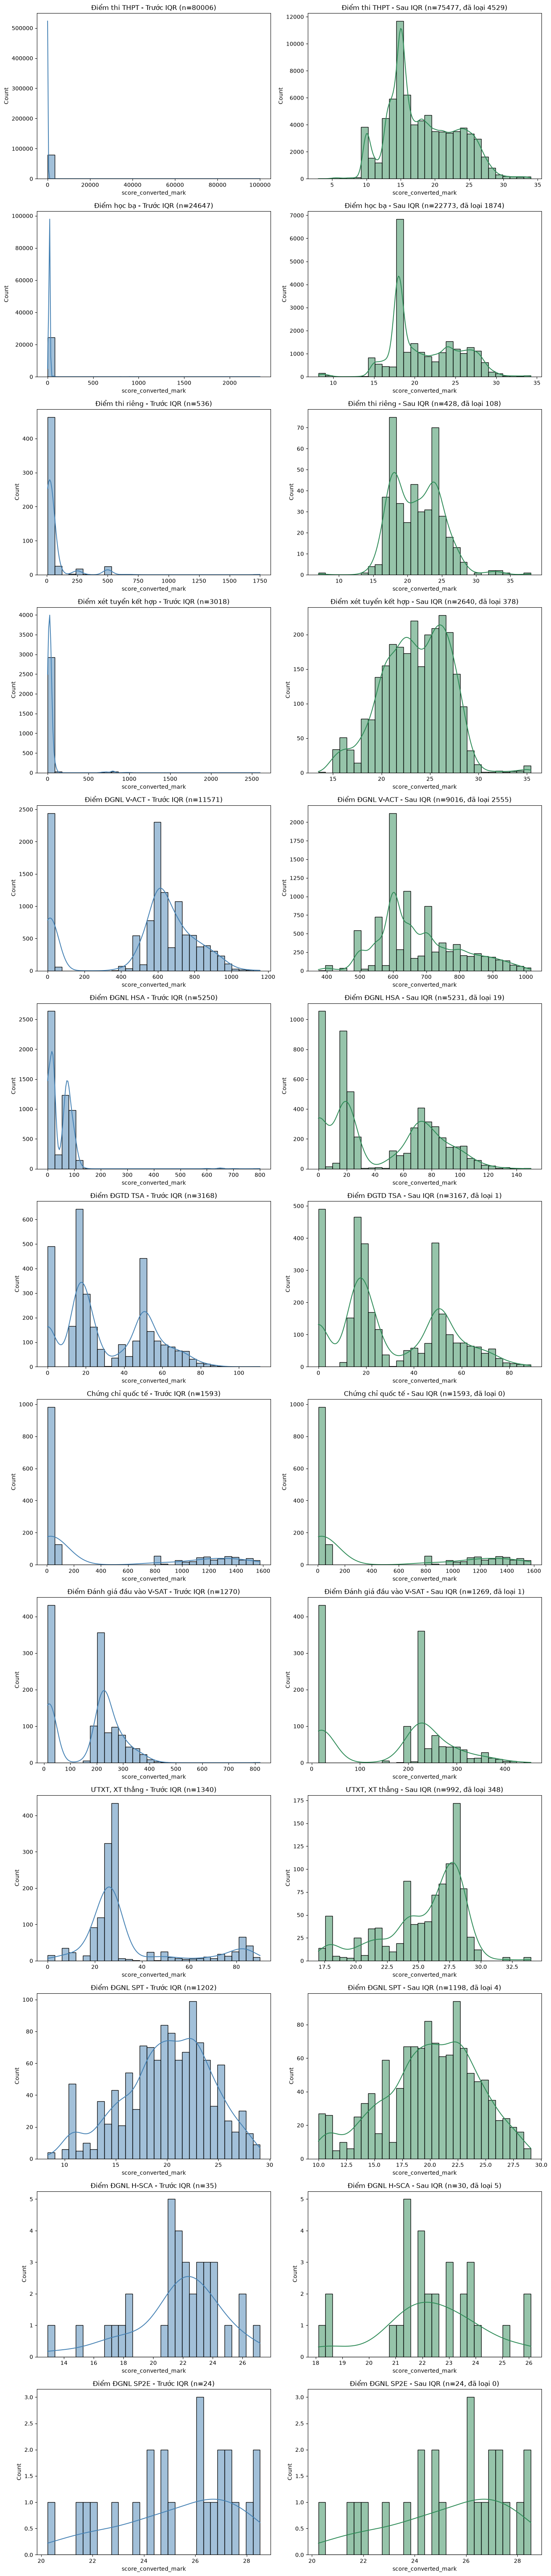

<class 'pandas.DataFrame'>
Index: 133660 entries, 6 to 147670
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   school_id             133660 non-null  str    
 1   school_name           133660 non-null  str    
 2   school_type           133660 non-null  str    
 3   school_short_name     125610 non-null  str    
 4   province_id           133660 non-null  int64  
 5   province_name         133660 non-null  str    
 6   score_code            133660 non-null  str    
 7   score_name            133660 non-null  str    
 8   score_blocks          109966 non-null  str    
 9   score_mark            133660 non-null  float64
 10  score_year            133660 non-null  int64  
 11  score_introtext       30655 non-null   str    
 12  score_admission_name  133660 non-null  str    
 13  score_converted_mark  133660 non-null  float64
dtypes: float64(2), int64(2), str(10)
memory usage: 15.3 MB


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_iqr_outlier_removal(df, group_col='score_admission_name', value_col='score_converted_mark'):
    """
    Với mỗi nhóm trong group_col:
    - Áp dụng phương pháp IQR để loại bỏ ngoại lai trên value_col
    - Vẽ 2 biểu đồ phân phối: trước và sau khi loại ngoại lai
    """
    groups = df[group_col].dropna().unique()
    n_groups = len(groups)

    fig, axes = plt.subplots(n_groups, 2, figsize=(14, 5 * n_groups))

    # Nếu chỉ có 1 nhóm, axes sẽ không phải mảng 2 chiều -> chuẩn hóa lại
    if n_groups == 1:
        axes = axes.reshape(1, 2)

    for i, group in enumerate(groups):
        subset = df.loc[df[group_col] == group, value_col].dropna()

        # --- Tính IQR ---
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        subset_filtered = subset[(subset >= lower_bound) & (subset <= upper_bound)]

        n_before = len(subset)
        n_after = len(subset_filtered)
        n_removed = n_before - n_after

        # --- Biểu đồ trước khi loại ngoại lai ---
        sns.histplot(subset, kde=True, bins=30, ax=axes[i, 0], color='steelblue')
        axes[i, 0].set_title(f'{group} - Trước IQR (n={n_before})')
        axes[i, 0].set_xlabel(value_col)
        axes[i, 0].set_ylabel('Count')

        # --- Biểu đồ sau khi loại ngoại lai ---
        sns.histplot(subset_filtered, kde=True, bins=30, ax=axes[i, 1], color='seagreen')
        axes[i, 1].set_title(f'{group} - Sau IQR (n={n_after}, đã loại {n_removed})')
        axes[i, 1].set_xlabel(value_col)
        axes[i, 1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()


# Gọi hàm
plot_iqr_outlier_removal(df, group_col='score_admission_name', value_col='score_converted_mark')
df.info()

## Chuẩn hóa mã khối và mã ngành (khóa ngoại)

In [13]:
print("\n=== THỐNG KÊ SAU KHI VALIDATE ===")
print(f"Số dòng ban đầu           : {len(df)}")

df_blocks = pd.read_csv(r'D:\UNI DOCS\OLAP\cleaned-data\cleaned-score-blocks.csv', encoding='utf-8')
df_majors = pd.read_csv(r'D:\UNI DOCS\OLAP\cleaned-data\cleaned-majors.csv', encoding='utf-8')

# ---- Chuẩn bị dữ liệu tra cứu ----
valid_block_codes = set(df_blocks['code'].dropna().astype(str).str.strip())

# Tách df_majors['score_codes'] theo ";" thành tập hợp các mã hợp lệ (thay vì so sánh substring)
major_score_codes_series = df_majors['score_codes'].dropna().astype(str)
valid_score_codes = set()
for val in major_score_codes_series:
    items = [x.strip() for x in val.split(';') if x.strip() != '']
    valid_score_codes.update(items)

# ---- Bước 1: Lọc từng item trong score_blocks (tách bởi ";", nếu block không tồn tại thì bỏ block - không bỏ dòng) ----
def clean_score_blocks(val):
    if pd.isna(val) or str(val).strip() == '':
        return val
    items = [x.strip() for x in str(val).split(';') if x.strip() != '']
    kept = [x for x in items if x in valid_block_codes]  # item IN df_blocks.code
    return ';'.join(kept) if kept else pd.NA

df['score_blocks'] = df['score_blocks'].apply(clean_score_blocks)

# ---- Bước 2: Bỏ cả dòng nếu score_code rỗng hoặc KHÔNG nằm trong tập các mã đã tách từ score_codes ----
def is_valid_score_code(val):
    if pd.isna(val) or str(val).strip() == '':
        return False
    code = str(val).strip()
    # code IN valid_score_codes
    return code in valid_score_codes

mask_valid = df['score_code'].apply(is_valid_score_code)
dropped_rows = df[~mask_valid]
df = df[mask_valid].reset_index(drop=True)

print(f"Số dòng bị loại (score_code không hợp lệ/rỗng): {len(dropped_rows)}")
print(f"Số dòng còn lại           : {len(df)}")
print(f"Số dòng có score_blocks bị loại hết (thành rỗng): {df['score_blocks'].isna().sum()}")

df.info()
df.head()


=== THỐNG KÊ SAU KHI VALIDATE ===
Số dòng ban đầu           : 133660
Số dòng bị loại (score_code không hợp lệ/rỗng): 22655
Số dòng còn lại           : 111005
Số dòng có score_blocks bị loại hết (thành rỗng): 36359
<class 'pandas.DataFrame'>
RangeIndex: 111005 entries, 0 to 111004
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   school_id             111005 non-null  str    
 1   school_name           111005 non-null  str    
 2   school_type           111005 non-null  str    
 3   school_short_name     107902 non-null  str    
 4   province_id           111005 non-null  int64  
 5   province_name         111005 non-null  str    
 6   score_code            111005 non-null  str    
 7   score_name            111005 non-null  str    
 8   score_blocks          74646 non-null   str    
 9   score_mark            111005 non-null  float64
 10  score_year            111005 non-null  int64  
 11  scor

,school_id,school_name,school_type,school_short_name,province_id,province_name,score_code,score_name,score_blocks,score_mark,score_year,score_introtext,score_admission_name,score_converted_mark
0,CKC,Trường Cao Đẳng Kỹ Thuật Cao Thắng,Cao đẳng,NaN,23,TP Hồ Chí Minh,6510304,Công nghệ Kỹ thuật Cơ điện tử,A00;A01,16.00,2018,NaN,Điểm thi THPT,16.00
1,CKC,Trường Cao Đẳng Kỹ Thuật Cao Thắng,Cao đẳng,NaN,23,TP Hồ Chí Minh,6510304,Công nghệ Kỹ thuật Cơ điện tử (đạt chuẩn KOSEN...,A00;A01;A02;D01;D07;C01;C02,23.00,2025,Điểm chuẩn trúng tuyển (Toán nhân 2),Điểm học bạ,17.25
2,CKC,Trường Cao Đẳng Kỹ Thuật Cao Thắng,Cao đẳng,NaN,23,TP Hồ Chí Minh,6510304,Công nghệ Kỹ thuật Cơ điện tử (đạt chuẩn KOSEN...,A00;A01;A02;D01;D07;C01;C02,17.25,2025,Quy đổi thang điểm 30,Điểm học bạ,17.25
3,CKC,Trường Cao Đẳng Kỹ Thuật Cao Thắng,Cao đẳng,NaN,23,TP Hồ Chí Minh,6510304,Công nghệ Kỹ thuật Cơ điện tử (đạt chuẩn KOSEN...,NaN,500.00,2025,NaN,Điểm ĐGNL V-ACT,500.00
4,CES,Trường Cao Đẳng Công Thương TPHCM,Cao đẳng,NaN,23,TP Hồ Chí Minh,6510304,Công nghệ kỹ thuật cơ điện tử,NaN,13.00,2024,NaN,Điểm thi THPT,13.00


In [14]:
output_path = r'D:\UNI DOCS\OLAP\cleaned-data\cleaned-cutoff-scores.csv'
df.to_csv(output_path, index=False)